# Discretizing the Richards Equation with Finite Elements
The goal is to discretize the Richards equation, the continuity equation for soil water in the vadose zone. The Richards equation is given by<br>

$\frac{\partial \theta}{\partial h_c}\frac{\partial h_c}{\partial t} - \nabla \cdot (k_r(h_c)K_s(e_z-\nabla h_c)) = W$ <br>

where $\theta$ is the volumetric water content, $h_c$ the capillary head, $k_r$ the relative permeability, $K_s$ the saturated hydraulic conductivity, $e_z$ the unit vector in $z$ direction and $W$ a source/sink term. The term $-k_r(h_c)K_s(e_z-\nabla h_c)$ is the Darcy velocity (cf Darcy's extended law for the unsaturated zone) and we denote it by $q:= - k_r(h_c)K_s(e_z-\nabla h_c) = -k_r(h_c)K_s\nabla(z-h_c).$ <br>
Here, we use the van Genuchten and Mualem parametrization to get: <br>

$k_r(S) = \sqrt{S} (1-(1-S^\frac{N}{N-1})^\frac{N-1}{N})^2,$ <br>
$S(h_c) = (1+(\alpha h_c)^N)^\frac{1-N}{N}$ and <br>
$S = \frac{\theta-\theta_r}{\theta_s-\theta_r}$ <br>

where $S$ is the saturation and $\alpha, N, \theta_r, \theta_s$ are soil-specific parameters which can be found in literature. <br>

We want to model a hillslope, so we are going to take a 2D-domain $\Omega$ in $z$- and $x$-direction and assume the following for boundary conditions on $\partial \Omega = \Gamma_{bed} \dot{\cup} \Gamma_{top} \dot{\cup} \Gamma_{D} \dot{\cup} \Gamma_{no}$: <br>
- the left hand side and the bottom are bounded by bedrock, so $q\cdot n = 0$ on $\Gamma_{bed}$
- the top gets constantly infiltrated (constant recharge), so $-q\cdot n = c_{in}$ on $\Gamma_{top}$
- at the right hand side an aquifer builds up to a certain height, such that $h_c=0$ on $\Gamma_D$ and above the water table water cannot flow out, i.e. $q\cdot n = 0$ on $\Gamma_{no}$. <br>
Here, $n$ denotes the unit vector normal to the boundary pointing outwards. <br>
Furthermore, as the initial condition we choose the hydrostatic assumption, i.e. <br>
$h_c(x,z,0) = \text{height above the groundwater table}$

This time, we do not assume steady-state, so we need some sort of time discretization. We choose a simple backward finite difference approach: <br>

$\frac{\theta_{n+1} - \theta_n}{\Delta t} - \nabla \cdot (k_{n+1} \nabla(z-h_{c,n+1}))=0$ <br>

where $n+1$ denotes the next time step and $t_{n+1}-t_n=\Delta t$, also $k_{n+1}=k_r(h_{c,n+1})K_s$. Transforming this now stationary equation into a variational formulation and denoting $u:=h_{c,n+1}$ we get: Find $u\in V$ such that <br>

$F(u;v)=\int_\Omega \theta(u)v\,dx + \Delta t \left[ \int_\Omega \nabla v \cdot k(u)\nabla(z-u) \,dx + \int_{\Gamma_{top}} vc_{in}\,ds \right] - \int_\Omega \theta(u_n) v\,dx = 0$ for all $v\in V$.

Where we assume the test function $v\in V=\{v\in H^1(\Omega):~ v=0 \text{ on } \Gamma_D\}$. 

This is now a nonlinear problem in $u$. We try and solve this via Picard iterations. <br>
**Picard iteration**: Find $u^{k+1}$ such that $\tilde{F}(u^{k+1};v)=0$ for all $v\in V$ for <br>

$\tilde{F}(u^{k+1};v) = \int_\Omega \theta(u^k)v\,dx + \Delta t \left[ \int_\Omega \nabla v \cdot k(u^k)\nabla(z-u^{k+1}) \,dx + \int_{\Gamma_{top}} vc_{in}\,ds \right] - \int_\Omega \theta(u_n) v\,dx$

 Now, $\tilde F$ is linear in both $u^{k+1}$ and $v$, so this can be solved by the LinearProblem solver.<br>


In [1]:
from dolfinx import default_scalar_type
from dolfinx.fem import (
    Constant,
    Function,
    Expression,
    functionspace,
    assemble_scalar,
    dirichletbc,
    form,
    locate_dofs_topological,
    locate_dofs_geometrical,
)
from dolfinx.fem.petsc import LinearProblem, NonlinearProblem
from dolfinx.io import XDMFFile
from dolfinx.mesh import create_unit_square, locate_entities, meshtags
from dolfinx.plot import vtk_mesh

from mpi4py import MPI
from ufl import (
    FacetNormal,
    Measure,
    SpatialCoordinate,
    TestFunction,
    TrialFunction,
    div,
    dot,
    dx,
    grad,
    inner,
    exp,
    ln,
    sqrt,
    lhs,
    rhs,
    conditional,
    sqrt,
)

from petsc4py import PETSc
import numpy as np
import pyvista

from visualization_fct import *

In [2]:
def create_quad_domain(comm, nx, ny, p0, p1, p2, p3):
    """
    Create a domain defined by four corner points.

    Args:
        comm (mpi4py.MPI.Intracomm): MPI communicator
        nx (int): number of cells in x-direction
        ny (int): number of cells in y-direction
        p0 (np.array): x and y coordinates of the bottom-left corner point
        p1 (np.array): x and y coordinates of the bottom-right corner point
        p2 (np.array): x and y coordinates of the top-right corner point
        p3 (np.array): x and y coordinates of the top-left corner point

    Returns:
        dolfinx.mesh: Domain defined by the corner points.
    """

    mesh = create_unit_square(comm, nx, ny)

    x = mesh.geometry.x
    xi = x[:, 0]
    eta = x[:, 1]

    x[:, :2] = (
        np.outer((1-xi)*(1-eta), p0) +
        np.outer(xi*(1-eta), p1) +
        np.outer(xi*eta, p2) +
        np.outer((1-xi)*eta, p3)
    )
    return mesh

2026-03-17 15:29:38.780 (   0.385s) [    7F434B469600]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


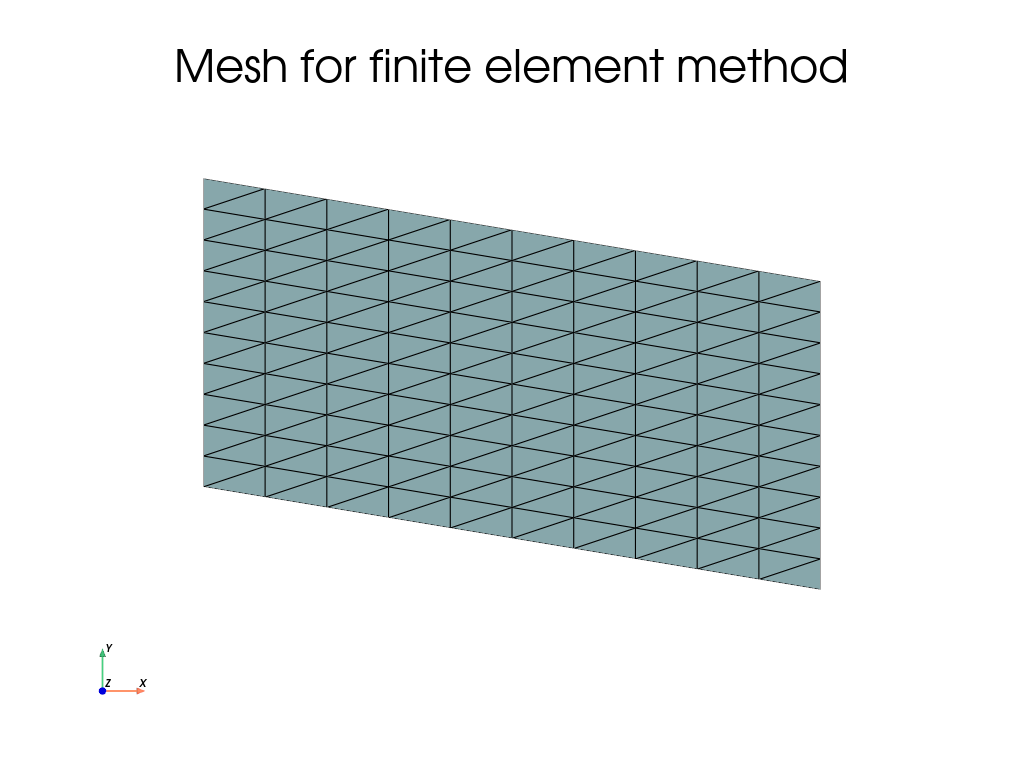

In [3]:
# Generate domain from four corner points
P0 = np.array([0, 0])
P1 = np.array([6, -1])
P2 = np.array([6, 2])
P3 = np.array([0, 3])
domain = create_quad_domain(MPI.COMM_WORLD, 10, 10, P0, P1, P2, P3)
plot_mesh2(domain)

### Define variational problem

In [4]:
# Define soil parameters for loam
alpha = 3.6
N = 1.56
theta_r = 0.078
theta_s = 0.43
Ks = 2.89e-6

In [5]:
# Define time discretization parameters
t = 0.0 # start time
delta_t = 1e-4 # step size
num_steps = 20
T = delta_t*num_steps 

In [6]:
# Create functionspace
V = functionspace(domain, ("CG", 1)) # linear Lagrange triangles
v = TestFunction(V)

def Saturation(u):
    eps = 1e-8
    u = sqrt(u**2 + eps) # only use 'safe' values > 0
    a1 = 1 + exp(ln(alpha * u)*N)
    exp1 = (1 - N) / N
    S = exp(ln(a1)*exp1)
    return S

def kr(u):
    S = Saturation(u)
    m = N / (N-1)
    a1 = 1 - exp(ln(S)*m)
    a2 = 1 - exp(ln(a1) / m)
    k = sqrt(S) * a2 ** 2
    return k

def theta(u):
    S = Saturation(u)
    return S*(theta_s - theta_r) + theta_r


x = SpatialCoordinate(domain)


### Define custom integration measures ds, boundary conditions
Following https://jsdokken.com/dolfinx-tutorial/chapter3/robin_neumann_dirichlet.html <br>
Define $\Gamma_{bed}$ to be boundary 1, $\Gamma_D$ boundary 2 (where we assume the groundwater table is at 0), $\Gamma_{out}$ is boundary 3 and $\Gamma_{in}$ boundary 4.

In [7]:
# Boundary conditions
slope = (P1[1]-P0[1])/(P1[0]-P0[0]) # slope of bottom and top boundary

# Define the gw table at the right boundary to be below 0.
def on_dirichlet(x):
    return np.logical_and(np.isclose(x[0], P1[0]), x[1] <= 0)
def gamma_out(x):
    return np.logical_and(np.isclose(x[0], P1[0]), x[1] >= 0)
def gamma_in(x):
    return np.isclose(x[1], slope*x[0]+P3[1])
def bottom(x):
    return np.isclose(x[1], slope*x[0])
def gamma_bed(x):
    return np.logical_or(bottom(x), np.isclose(x[0], 0))

In [8]:
boundaries = [
    (1, gamma_bed),
    (2, on_dirichlet),
    (3, gamma_out),
    (4, gamma_in)
]

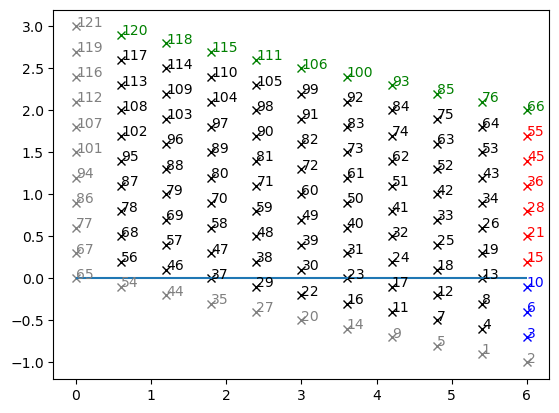

In [9]:
# Check, if the right boundaries are identified
pts = domain.geometry.x # mesh coordinates of the vertices shape=(num_points, 3)
pts = np.array(pts)
import matplotlib.pyplot as plt
for i, p in enumerate(pts):
    i += 1
    if gamma_bed(p):
        c = "grey"
    elif gamma_in(p):
        c = "green"
    elif gamma_out(p):
        c = "red"
    elif on_dirichlet(p):
        c = "blue"
    else:
        c = "black"
    plt.plot(p[0], p[1], 'x', color=c)
    plt.annotate(str(i), (p[0], p[1]), color=c)
plt.hlines(0, min(pts[:,0]), max(pts[:,0]))

In [10]:
# We now loop through all the boundary conditions and create MeshTags identifying the facets for each boundary condition.
facet_indices, facet_markers = [], []
fdim = domain.topology.dim - 1
for marker, locator in boundaries:
    facets = locate_entities(domain, fdim, locator) # find boundary facet
    facet_indices.append(facets)
    facet_markers.append(np.full_like(facets, marker))
facet_indices = np.hstack(facet_indices).astype(np.int32) # make array of arrays into single array
facet_markers = np.hstack(facet_markers).astype(np.int32)
sorted_facets = np.argsort(facet_indices)
facet_tag = meshtags(
    domain, fdim, facet_indices[sorted_facets], facet_markers[sorted_facets]
) # each boundary facet gets identified with its boundary condition

domain.topology.create_connectivity(fdim, domain.topology.dim) # connect facets to cells

In [11]:
# Create custom integration measure
ds = Measure("ds", domain, subdomain_data=facet_tag)

I think this is not needed in this instance

In [12]:
# Create general boundary condition class
class BoundaryCondition:
    def __init__(self, type, marker, values):
        self._type = type
        if type == "Dirichlet":
            facets = facet_tag.find(marker)
            dofs = locate_dofs_topological(V, fdim, facets)
            self._bc = dirichletbc(PETSc.ScalarType(values), dofs, V)
        elif type == "Neumann":
            self._bc = inner(values, v) * ds(marker)
        else:
            raise TypeError("Unknown boundary condition: {0:s}".format(type))

    @property
    def bc(self):
        return self._bc

    @property
    def type(self):
        return self._type

In [13]:
# Define boundary conditions
c_in = 2e-9 # recharge
c_out = 1e-10 # outflow
boundary_conditions = [
    BoundaryCondition("Neumann", 1, Constant(domain, default_scalar_type(0))),
    BoundaryCondition("Dirichlet", 2, 0),
    BoundaryCondition("Neumann", 3, Constant(domain, default_scalar_type(0))),
    BoundaryCondition("Neumann", 4, Constant(domain, default_scalar_type(c_in)))
]

In [14]:
bcs = []
#F = dot(kr(u)*Ks*grad(x[1] - u), grad(v))*dx
for condition in boundary_conditions:
    if condition.type == "Dirichlet":
        bcs.append(condition.bc)
    #else:
        # F += condition.bc

### Start time and Picard iteration

In [15]:
# Initial condition: hydrostatic (h_c = height above gw table)
def u_ini(x):
    return np.maximum(x[1], 0)

u_n = Function(V) # function for previous time step
u_n.interpolate(u_ini)

u_k = Function(V) # function for Picard previous step
u_k.interpolate(u_ini)

u = TrialFunction(V)

F_tilde = (theta(u_k)- theta(u_n))/delta_t * v * dx + inner(kr(u_k) * Ks * grad(x[1] - u), grad(v)) * dx - v*c_in*ds(4)
a = lhs(F_tilde)
L = rhs(F_tilde)



maxit = 10
tol = 1e-3

for n in range(1):
    k = 0
    eps = 1

    u_k.x.array[:] = u_n.x.array # initial guess = small pertubation of previous time step 
    u = Function(V)
    while k < maxit and eps > tol:
        
        problem = LinearProblem(
            a, L, bcs=bcs,
            petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
            petsc_options_prefix="Richards_Transient_"
        )
        u = problem.solve()
        u.x.array[:] = np.maximum(u.x.array, 0) # make sure capillary head stays nonnegative
        print(u.x.array)
        diff = u.x.array - u_k.x.array
        eps = np.linalg.norm(diff, ord=2)
        print(f"Time step {n+1}, Iteration {k}, Error ||u_k-u_(k+1)|| {eps:.3e}")
        omega = 0.2
        u_k.x.array[:] = (1 - omega) * u_k.x.array + omega * u.x.array
        #u_k.x.array[:] = u.x.array # update Picard iteration step
        k += 1
    
    u_n.x.array[:] = u.x.array # update time step solution
    

[0.         0.         0.         0.         0.         0.
 0.         0.12859219 0.         0.         0.05015227 0.24670267
 0.39074924 0.         0.34960494 0.14713788 0.34860947 0.539301
 0.6723299  0.         0.68984081 0.24458253 0.44678215 0.64677575
 0.82922812 0.94489252 0.04207352 0.99544975 0.34182767 0.54420009
 0.74525628 0.93717409 1.09542529 1.17706053 0.13963575 1.20564197
 0.43943561 0.64116246 0.84079015 1.03036561 1.19305194 1.29577517
 1.3014743  0.23727426 1.2294435  0.53688401 0.73814116 0.93390636
 1.11582048 1.26699178 1.35982147 1.3537011  1.21196819 0.33433516
 0.93766555 0.63378834 0.83352615 1.02400108 1.1936483  1.32445608
 1.38874376 1.34762404 1.15246997 0.76022043 0.43281296 0.15789373
 0.73174193 0.92664116 1.10877583 1.26207373 1.36504521 1.38830991
 1.29215998 1.02595963 0.53126178 0.         1.0174768  1.1863846
 1.3178063  1.38576994 1.35722357 1.19014792 0.83190945 0.21945055
 0.         1.25477407 1.35746837 1.38206305 1.29116103 1.03884268
 0.569

/tmp/ipykernel_3997489/2948568991.py:38: RuntimeWarning: invalid value encountered in subtract
  diff = u.x.array - u_k.x.array


### Try with Newton since Picard blows up ffs

In [29]:
# Initial condition: hydrostatic (h_c = height above gw table)
def u_ini(x):
    return np.maximum(x[1], 0)

u_n = Function(V) # function for previous time step
u_n.interpolate(u_ini)

u = TrialFunction(V)

F = (theta(u) - theta(u_n))/delta_t * v * dx + inner(kr(u)*Ks*grad(x[1] - u), grad(v)) * dx - v*c_in*ds(4)

In [34]:
from ufl import derivative, Coefficient
du = Coefficient(V)
F = (theta(du) - theta(u_n))/delta_t * v * dx + inner(kr(du)*Ks*grad(x[1] - du), grad(v)) * dx - v*c_in*ds(4)
J = derivative(F, du)

from dolfinx.fem.petsc import LinearProblem, assemble_vector
from petsc4py import PETSc

maxit = 10
tol = 1e-6

u = Function(V)

for n in range(num_steps):
    k = 0
    eps = 1.0

    # initial guess
    u.x.array[:] = u_n.x.array

    while k < maxit and eps > tol:
        # Assemble residual and Jacobian
        F_form = (theta(u) - theta(u_n))/delta_t*v*dx \
                 + inner(kr(u)*Ks*grad(x[1] - u), grad(v))*dx \
                 - v*c_in*ds(4)

        du = TrialFunction(V)
        J_form = derivative(F_form, u, du)

        problem = LinearProblem(J_form, -F_form, bcs=bcs,
                                petsc_options={"ksp_type":"preonly","pc_type":"lu"},                                 petsc_options_prefix="Richards_Transient_")

        delta_u = problem.solve()

        # Update solution
        u.x.array[:] += delta_u.x.array
        eps = np.linalg.norm(delta_u.x.array, ord=2)
        print(f"Time {n+1}, Newton iter {k}, ||delta_u||={eps:.3e}")

        k += 1

    # update previous time step
    u_n.x.array[:] = u.x.array[:]

Time 1, Newton iter 0, ||delta_u||=1.560e+00
Time 1, Newton iter 1, ||delta_u||=2.500e+00
Time 1, Newton iter 2, ||delta_u||=1.702e+00
Time 1, Newton iter 3, ||delta_u||=1.996e+00
Time 1, Newton iter 4, ||delta_u||=3.775e+00
Time 1, Newton iter 5, ||delta_u||=6.677e+00
Time 1, Newton iter 6, ||delta_u||=1.029e+01
Time 1, Newton iter 7, ||delta_u||=1.917e+01
Time 1, Newton iter 8, ||delta_u||=8.206e+01
Time 1, Newton iter 9, ||delta_u||=9.564e+02
Time 2, Newton iter 0, ||delta_u||=1.346e-04
Time 2, Newton iter 1, ||delta_u||=9.173e-05
Time 2, Newton iter 2, ||delta_u||=1.494e-04
Time 2, Newton iter 3, ||delta_u||=1.448e-04
Time 2, Newton iter 4, ||delta_u||=3.140e-04
Time 2, Newton iter 5, ||delta_u||=3.917e-04
Time 2, Newton iter 6, ||delta_u||=8.974e-04
Time 2, Newton iter 7, ||delta_u||=1.209e-03
Time 2, Newton iter 8, ||delta_u||=2.798e-03
Time 2, Newton iter 9, ||delta_u||=4.310e-03
Time 3, Newton iter 0, ||delta_u||=1.362e-04
Time 3, Newton iter 1, ||delta_u||=9.212e-05
Time 3, Ne

Also das macht was, aber ich glaub nicht das richtige, siehe unten...

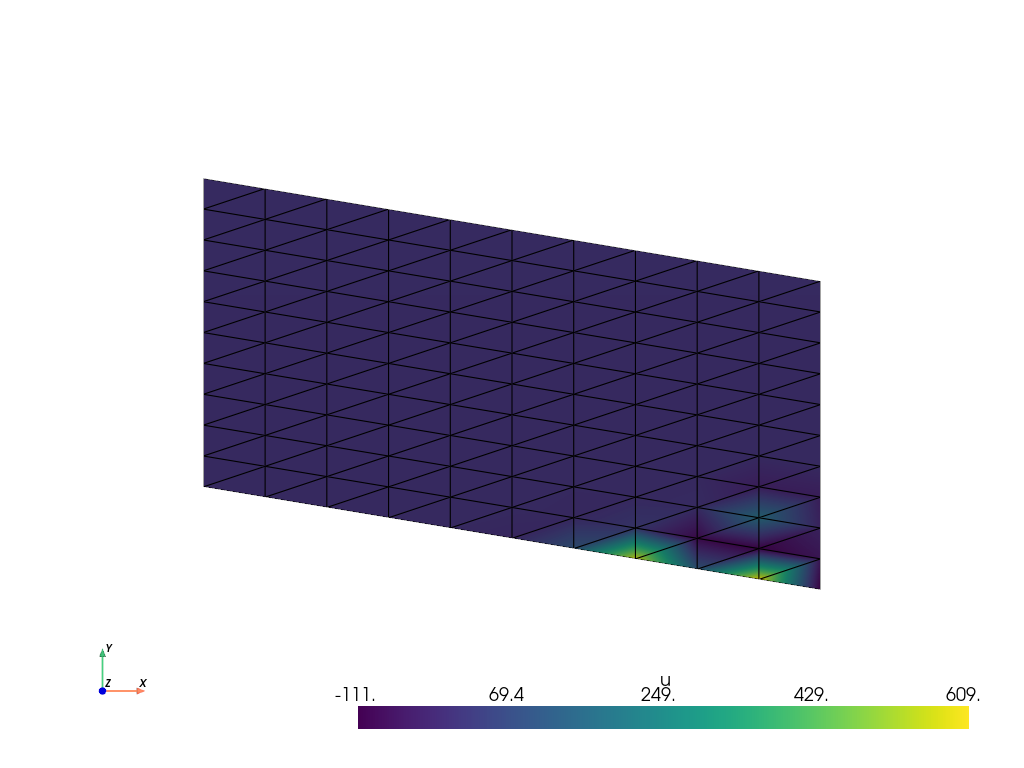

In [35]:
plotScalarFunction(V, u)